# Pipeline 6 - Triangle proposed by MJ

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
OUTPUT_DIR = "/data/swot/output"

## Read the sites and dates

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
from rasterio.enums import Resampling

from swot_toolkit.analysis import open_sites_and_dates
from swot_toolkit.metrics import calc_metrics
from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe4 import open_datasets
from swot_toolkit.swot import create_raster_mosaic


In [5]:
OUTPUT_DIR = Path("/data/swot/output")
sites_dates = open_sites_and_dates(OUTPUT_DIR)


## Best performing scenarios

Here, we will combine all the results that used the reference mask. Hopefully, all these values will be already calculated in each site dir. 

In [6]:
overall_results = pd.DataFrame()

for site, dates in sites_dates.items():
    for date in dates:
        # Open the dir and the raster mosaic
        base_dir, aoi, s2_id = open_output_dir(site, date)

        results = pd.read_parquet(base_dir / "results.parquet")
        site_date = f"{site} {date}"
        results.index = pd.MultiIndex.from_product([[site_date], results.index])

        overall_results = pd.concat([overall_results, results], axis=0)


Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml
Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml
Reading KML file: /data/swot/output/Rio_Madeira/kml/Rio_Madeira.kml
Reading KML file: /data/swot/output/Rio_Negro/kml/Rio_Negro.kml


In [7]:
overall_results

opera_s2  opera_s2 incl. partial  opera_s1  \
Curua-Una 2025-08-14   iou          0.8985                  0.8374    0.8607   
                       f1           0.9465                  0.9115    0.9252   
                       precision    0.9963                  0.8673    0.9974   
                       recall       0.9015                  0.9605    0.8627   
Northeast 2025-07-20   iou          0.8573                  0.7756    0.6738   
                       f1           0.9232                  0.8736    0.8051   
                       precision    0.9518                  0.8182    0.9896   
                       recall       0.8962                  0.9371    0.6786   
Rio_Branco 2025-09-07  iou          0.7739                  0.7832    0.6903   
                       f1           0.8725                  0.8784    0.8168   
                       precision    0.9982                  0.8525    0.9941   
                       recall       0.7750                  0.9059    0.6931   
Rio_Madeira 2025-07-21 iou          0.9297                  0.8590    0.9020   
                       f1           0.9636                  0.9242    0.9485   
                       precision    0.9974                  0.8820    0.9940   
                       recall       0.9320                  0.9706    0.9069   
Rio_Negro 2025-08-07   iou          0.9474                  0.8863    0.8713   
                       f1           0.9730                  0.9397    0.9313   
                       precision    0.9964                  0.8969    0.9998   
                       recall       0.9506                  0.9868    0.8715   

                                  opera_s1 incl. partial   as is  \
Curua-Una 2025-08-14   iou                        0.8496  0.7582   
                       f1                         0.9187  0.8625   
                       precision                  0.9788  0.9217   
                       recall                     0.8655  0.8104   
Northeast 2025-07-20   iou                        0.6674  0.3661   
                       f1                         0.8005  0.5359   
                       precision                  0.9464  0.9015   
                       recall                     0.6936  0.3813   
Rio_Branco 2025-09-07  iou                        0.7310  0.5682   
                       f1                         0.8446  0.7247   
                       precision                  0.9285  0.7807   
                       recall                     0.7747  0.6762   
Rio_Madeira 2025-07-21 iou                        0.8999  0.7352   
                       f1                         0.9473  0.8474   
                       precision                  0.9908  0.8226   
                       recall                     0.9075  0.8738   
Rio_Negro 2025-08-07   iou                        0.8694  0.7779   
                       f1                         0.9301  0.8751   
                       precision                  0.9947  0.8959   
                       recall                     0.8734  0.8551   

                                  exclude no data  exclude bad  \
Curua-Una 2025-08-14   iou                 0.7974       0.8111   
                       f1                  0.8873       0.8957   
                       precision           0.9450       0.9250   
                       recall              0.8362       0.8682   
Northeast 2025-07-20   iou                 0.7679       0.7679   
                       f1                  0.8687       0.8687   
                       precision           0.8715       0.8715   
                       recall              0.8659       0.8659   
Rio_Branco 2025-09-07  iou                 0.5423       0.5704   
                       f1                  0.7032       0.7265   
                       precision           0.7768       0.7678   
                       recall              0.6424       0.6893   
Rio_Madeira 2025-07-21 iou                 0.7750       0.7744   


In [8]:
median = overall_results.groupby(level=1).median()
median.loc[["iou", "f1", "precision", "recall"]]

,opera_s2,opera_s2 incl. partial,opera_s1,opera_s1 incl. partial,as is,exclude no data,exclude bad,"exclude (bad, degraded)","exclude (bad, degraded, suspect)"
iou,0.8985,0.8374,0.8607,0.8496,0.7352,0.7750,0.7744,0.7679,0.2772
f1,0.9465,0.9115,0.9252,0.9187,0.8474,0.8733,0.8729,0.8687,0.4341
precision,0.9964,0.8673,0.9941,0.9788,0.8959,0.8715,0.8715,0.8715,0.9678
recall,0.9015,0.9605,0.8627,0.8655,0.8104,0.8659,0.8682,0.8659,0.2798


## Triangle pre-process (takes time but is pre-calculated)

From the previous section, we have the best scenarios as :
* opera without partial water
* swot excluding no data

First, we will calculate, for each site, a parquet with the results considering one of the datasets as reference. They will be saved with the format `results_ref_mask.parquet`, `results_opera_s1.parquet`, etc..

In [9]:
metrics = ["iou", "f1", "precision", "recall"]


In [ ]:
from swot_toolkit.metrics import process_opera_mask, process_swot_mask
from swot_toolkit.pipe4 import create_swot_mosaic, open_datasets

for site, dates in sites_dates.items():
    for date in dates:
        base_dir, aoi, s2_id = open_output_dir(site, date)
        # mosaic_df = pd.read_parquet(base_dir.parent / "dfs/swot_raster_results.parquet")

        # Load the datasets
        datasets = open_datasets(site, date)

        # process opera_masks
        for opera_mask in ["opera_s2", "opera_s1"]:
            datasets[opera_mask] = process_opera_mask(datasets[opera_mask], include_partial=False)
            # mask = datasets[opera_mask]
            # mask = mask.fillna(3).astype(np.uint8)
            # mask.data[mask.data == 2] = 0  # partial water to non-water
            # mask.data[mask.data >= 200] = 3  # no data to flagged
            # datasets[opera_mask] = mask

        # Create the SWOT mosaic
        swot_mask, patches, no_data_masks = create_swot_mosaic(
            region_name=site,
            ref_date=date,
            exclude_flags=None,
            dst_crs=datasets["ref_mask"].rio.crs,
            exclude_no_data=True,
        )

        swot_mask = process_swot_mask(swot_mask, water_threshold=0.6)
        # swot_mask = swot_mask["water_frac"]
        # swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
        # swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.6)] = 0  # not water
        # swot_mask.data[swot_mask.data < -1] = 0  # not water
        # swot_mask.data[swot_mask.data == -1] = 3  # flagged
        # swot_mask = swot_mask.fillna(2).astype("uint8")
        datasets["swot"] = swot_mask

        # Now we have to loop through the multiple datasets to be the reference
        for ref_mask_name in ["ref_mask", "opera_s2", "opera_s1", "swot"]:
            # For each reference mask, we will create a dataframe to store the results
            results = pd.DataFrame()

            ref_mask = datasets[ref_mask_name].copy()
            ref_mask.data[ref_mask.data == 3] = 2  # flagged to no data

            # Now we loop through all the masks to compare to the reference
            for mask_name in ["ref_mask", "opera_s2", "opera_s1", "swot"]:
                mask = datasets[mask_name].copy()

                # Change any flagged value in the reference to no data
                # ref_mask.data[ref_mask.data == 255] = 2  # no data to no data

                # Now, we will calculate the metrics for all datasets considering ref_mask as reference
                stats = calc_metrics(ref_mask, mask, metrics, binary=True)
                stats = stats.rename(columns={0: mask_name})

                results = pd.concat([results, stats], axis=1)

            # At this point, we have our results considering ref_mask_name as reference
            results.to_parquet(base_dir / f"results_{ref_mask_name}_as_reference.parquet")


The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']


## Triangle creation

In [11]:
overall_results = pd.DataFrame()
for site, dates in sites_dates.items():
    for date in dates:
        # Open the dir and the raster mosaic
        base_dir, aoi, s2_id = open_output_dir(site, date)

        site_results = pd.DataFrame()
        for ref_mask_name in ["ref_mask", "opera_s2", "opera_s1", "swot"]:
            results = pd.read_parquet(base_dir / f"results_{ref_mask_name}_as_reference.parquet")
            results = results.loc[["iou"]]
            results.index = [ref_mask_name]
            site_results = pd.concat([site_results, results], axis=0)

        site_results.index = pd.MultiIndex.from_product([[f"{site} {date}"], site_results.index])

        overall_results = pd.concat([overall_results, site_results], axis=0)


In [12]:
overall_results

ref_mask  opera_s2  opera_s1    swot
Curua-Una 2025-08-14   ref_mask    1.0000    0.8985    0.8607  0.7874
                       opera_s2    0.9304    1.0000    0.9000  0.8249
                       opera_s1    0.8607    0.8663    1.0000  0.8313
                       swot        0.7874    0.8011    0.8313  1.0000
Northeast 2025-07-20   ref_mask    1.0000    0.8573    0.6738  0.7684
                       opera_s2    0.8597    1.0000    0.7015  0.7653
                       opera_s1    0.6741    0.7005    1.0000  0.6721
                       swot        0.7684    0.7644    0.6720  1.0000
Rio_Branco 2025-09-07  ref_mask    1.0000    0.7739    0.6903  0.5299
                       opera_s2    0.8242    1.0000    0.7787  0.5933
                       opera_s1    0.6903    0.7193    1.0000  0.6060
                       swot        0.5299    0.5544    0.6060  1.0000
Rio_Madeira 2025-07-21 ref_mask    1.0000    0.9297    0.9020  0.7757
                       opera_s2    0.9389    1.0000    0.9481  0.8010
                       opera_s1    0.9020    0.9417    1.0000  0.7921
                       swot        0.7757    0.8003    0.7921  1.0000
Rio_Negro 2025-08-07   ref_mask    1.0000    0.9474    0.8713  0.7764
                       opera_s2    0.9476    1.0000    0.9089  0.7923
                       opera_s1    0.8714    0.9087    1.0000  0.7784
                       swot        0.7764    0.7922    0.7784  1.0000

In [29]:
matrix = (
    overall_results.groupby(level=1).median().loc[["ref_mask", "opera_s2", "opera_s1", "swot"]]
)

matrix.index.name = "Reference"
matrix

,ref_mask,opera_s2,opera_s1,swot
Reference,,,,
ref_mask,1.0000,0.8985,0.8607,0.7757
opera_s2,0.9304,1.0000,0.9000,0.7923
opera_s1,0.8607,0.8663,1.0000,0.7784
swot,0.7757,0.7922,0.7784,1.0000


In [26]:
rename_dict = {
    "ref_mask": "Reference",
    "opera_s2": "OPERA-S2",
    "opera_s1": "OPERA-S1",
    "swot": "SWOT",
}
matrix = matrix.rename(columns=rename_dict, index=rename_dict)

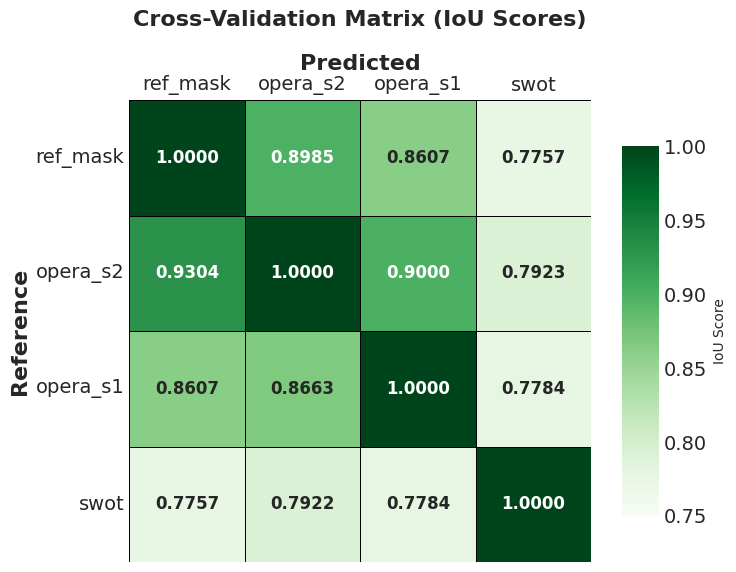

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    matrix,
    annot=True,  # Show values in cells
    cmap="Greens",  # Green colormap
    square=True,  # Square cells
    linewidths=0.5,  # Grid lines
    linecolor="black",  # Grid line color
    fmt=".4f",  # Number format
    cbar_kws={"label": "IoU Score", "shrink": 0.8, "aspect": 10},
    annot_kws={"size": 12, "weight": "bold"},
    vmin=0.75,
)

# Move x-axis labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title("Cross-Validation Matrix (IoU Scores)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Predicted", fontsize=16, fontweight="bold")
plt.ylabel("Reference", fontsize=16, fontweight="bold")

# Increase axis text size
plt.xticks(fontsize=14, rotation=0, ha='center')
plt.yticks(fontsize=14, rotation=0)

# Increase colorbar tick size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.

# plt.tight_layout()
plt.show()

## No Data vs flags Investigation

The idea here is to check whether or not the vectorial no data exclusion is really necessary

In [39]:
from swot_toolkit.analysis import open_sites_and_dates

In [51]:
metrics = ["iou", "f1", "precision", "recall"]

In [40]:
sites_dates = open_sites_and_dates("/data/swot/output")

In [201]:
quality_flags_bad = [
    "value_bad",
    "outside_data_window",
    "no_pixels",
    "outside_scene_bounds",
    "inner_swath",
    "missing_karin_data",
]

experiments = {
    "as is": {"exclude_no_data": False, "exclude_flags": None},
    "vectorial exclusion": {"exclude_no_data": True, "exclude_flags": None},
    "flags exclusion": {
        "exclude_no_data": False,
        "exclude_flags": ["inner_swath", "outside_data_window", "outside_scene_bounds"],
    },
}


In [229]:
# Let's loop through all the sites and dates to calculate the results
results = {}
all_results = pd.DataFrame()
for site, dates in sites_dates.items():
    results[site] = {}
    for date in dates:
        base_dir, aoi, s2_id = open_output_dir(site, date)
        mosaic_df = pd.read_parquet(base_dir.parent / "dfs/swot_raster_results.parquet")

        # Load the datasets
        datasets = open_datasets(site, date)

        ref_mask = datasets["ref_mask"].copy()
        ref_mask.data[ref_mask.data == 3] = 2  # flagged to no data

        # Now we loop through the experiments
        site_results = pd.DataFrame()
        for experiment, values in experiments.items():
            # Create the SWOT mosaic
            swot_mask, patches, no_data_masks = create_raster_mosaic(
                mosaic_df,
                ref_date=date,
                aoi=aoi,
                variable="water_frac",
                exclude_flags=values["exclude_flags"],
                dst_crs=datasets["ref_mask"].rio.crs,
                exclude_no_data=values["exclude_no_data"],
            )
            swot_mask = swot_mask["water_frac"].copy()
            swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
            swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.6)] = 0  # not water
            swot_mask.data[swot_mask.data < -1] = 0  # not water
            swot_mask.data[swot_mask.data == -1] = 3  # flagged
            swot_mask = swot_mask.fillna(2).astype("uint8")
            results[site][experiment] = {
                "mask": swot_mask,
                "patches": patches,
                "no_data_masks": no_data_masks,
            }

            stats = calc_metrics(ref_mask, swot_mask, metrics, binary=True)
            stats = stats.rename(columns={0: experiment})
            site_results = pd.concat([site_results, stats], axis=1)

    site_results.index = pd.MultiIndex.from_product([[f"{site} {date}"], site_results.index])
    all_results = pd.concat([all_results, site_results], axis=0)


Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml
Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Reading KML file: /data/swot/output/Rio_Madeira/kml/Rio_Madeira.kml
Reading KML file: /data/swot/output/Rio_Madeira/kml/Rio_Madeira.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Reading KML file: /data/swot/output/Rio_Negro/kml/Rio_Negro.kml
Reading KML file: /data/swot/out

In [231]:
median = all_results.groupby(level=1).median()
median.index = pd.MultiIndex.from_product([["median"], median.index])


pd.concat([all_results, median], axis=0)

as is  vectorial exclusion  flags exclusion
Curua-Una 2025-08-14   iou        0.7518               0.7874           0.8060
                       f1         0.8583               0.8810           0.8926
                       precision  0.9374               0.9526           0.9367
                       recall     0.7915               0.8195           0.8524
Northeast 2025-07-20   iou        0.3575               0.7684           0.7684
                       f1         0.5267               0.8690           0.8690
                       precision  0.9245               0.9004           0.9004
                       recall     0.3683               0.8398           0.8398
Rio_Branco 2025-09-07  iou        0.5540               0.5299           0.5570
                       f1         0.7130               0.6927           0.7155
                       precision  0.8002               0.7888           0.7840
                       recall     0.6429               0.6174           0.6579
Rio_Madeira 2025-07-21 iou        0.7398               0.7757           0.7777
                       f1         0.8505               0.8737           0.8749
                       precision  0.8389               0.8504           0.8440
                       recall     0.8623               0.8983           0.9083
Rio_Negro 2025-08-07   iou        0.7704               0.7764           0.7816
                       f1         0.8703               0.8741           0.8774
                       precision  0.9112               0.8973           0.8911
                       recall     0.8329               0.8521           0.8641
median                 f1         0.8505               0.8737           0.8749
                       iou        0.7398               0.7757           0.7777
                       precision  0.9112               0.8973           0.8911
                       recall     0.7915               0.8398           0.8524

In [210]:
experiment, results["Curua-Una"].keys()

('flags exclusion',
 dict_keys(['as is', 'vectorial exclusion', 'flags exclusion']))

In [211]:
# Create the SWOT mosaic
swot_mask, patches, no_data_masks = create_raster_mosaic(
    mosaic_df,
    ref_date=date,
    aoi=aoi,
    variable="water_frac",
    exclude_flags=values["exclude_flags"],
    dst_crs=datasets["ref_mask"].rio.crs,
    exclude_no_data=values["exclude_no_data"],
)

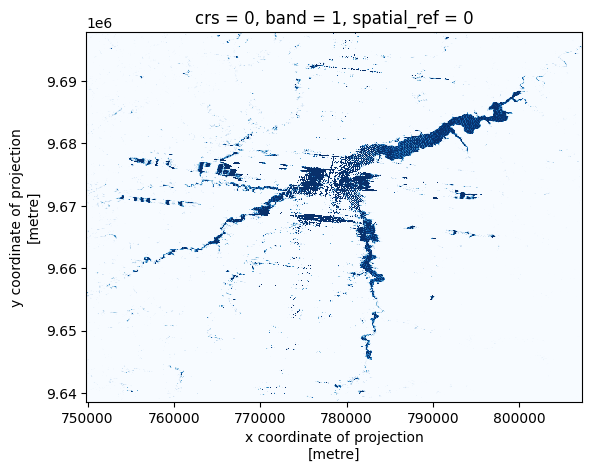

In [221]:
import matplotlib.pyplot as plt

patches[0]["water_frac"].plot(vmin=0, vmax=1, cmap="Blues", add_colorbar=False)

no_data = patches[0]["water_area_qual_bitwise"].copy()
no_data.data = no_data_masks[0]
# patches[0]["water_frac"].where(no_data_masks[0]).plot(
#     vmin=-1, vmax=-1,
#     cmap="Reds",
#     add_colorbar=False,
# )

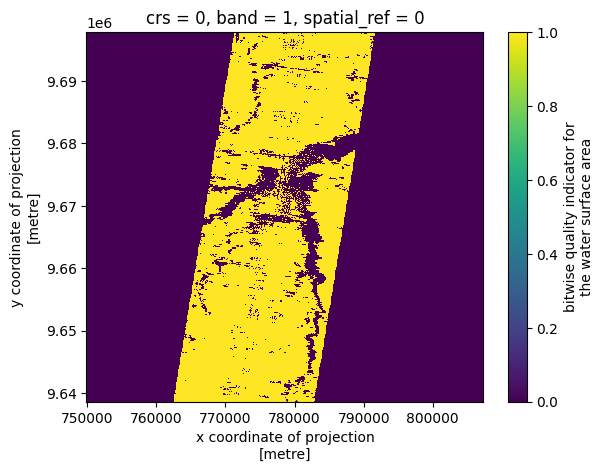

In [222]:
no_data.plot()

In [216]:
patches[0]["water_frac"].where(no_data_masks[0]).mean()

<xarray.DataArray 'water_frac' ()> Size: 4B
array(-1., dtype=float32)
Coordinates:
    crs          int64 8B 0
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [188]:
swot_mask = swot_mask["water_frac"].copy()
swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.6)] = 0  # not water
swot_mask.data[swot_mask.data < -1] = 0  # not water
swot_mask.data[swot_mask.data == -1] = 3  # flagged
swot_mask = swot_mask.fillna(2).astype("uint8")

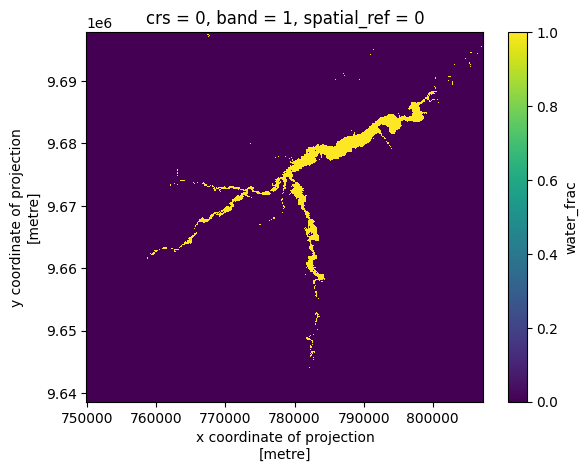

In [180]:
swot_mask.plot()

In [190]:
calc_metrics(ref_mask, swot_mask, metrics, binary=True)

,0
iou,0.8060
f1,0.8926
precision,0.9367
recall,0.8524


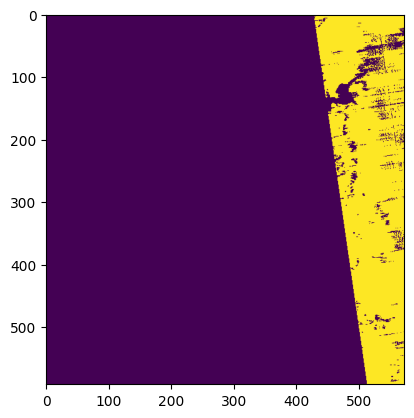

In [167]:
plt.imshow(no_data_masks[1])

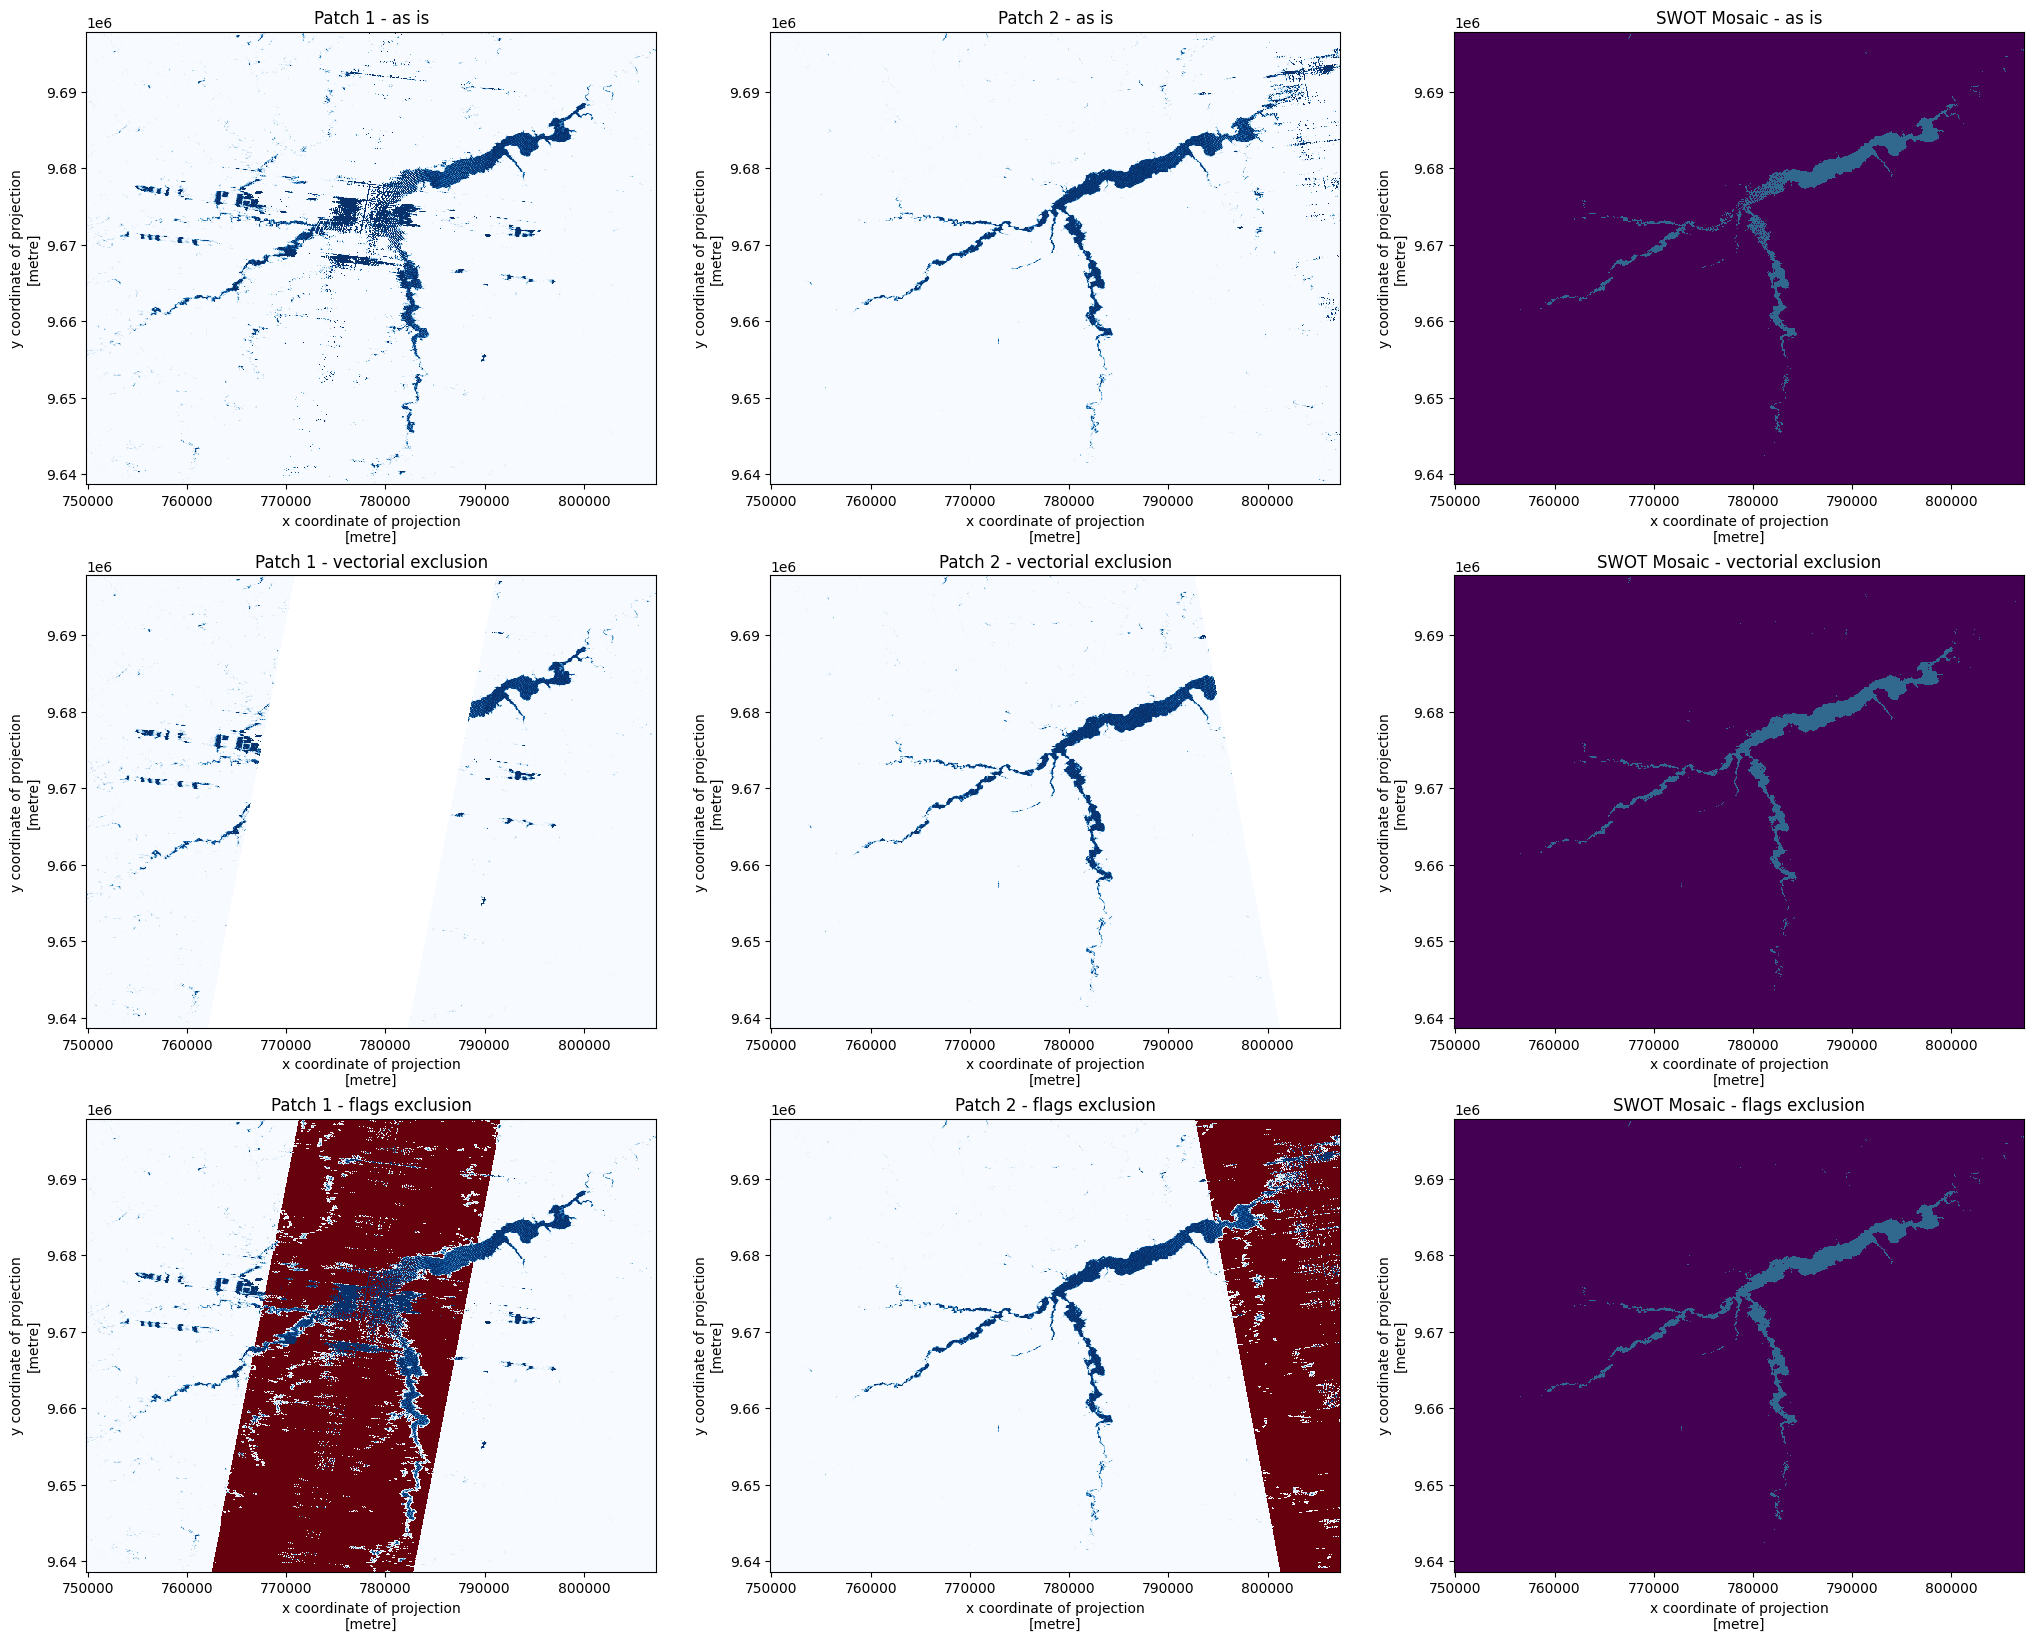

In [233]:
import matplotlib.pyplot as plt

SITE = "Curua-Una"
# SITE = "Northeast"

fig, axs = plt.subplots(3, 3, figsize=(25, 20))


for j, experiment in enumerate(experiments.keys()):
    patches = results[SITE][experiment]["patches"]
    no_data_masks = results[SITE][experiment]["no_data_masks"]

    for i, patch in enumerate(patches):
        patch["water_frac"].plot(ax=axs[j, i], vmin=0, vmax=1, cmap="Blues", add_colorbar=False)

        # Plot the no_data in the patch
        no_data = patch["water_area_qual_bitwise"].copy()
        no_data.data = no_data_masks[i]
        no_data = no_data.where(no_data)
        no_data.plot(ax=axs[j, i], vmin=0, vmax=1, cmap="Reds", add_colorbar=False, alpha=1)
        axs[j, i].set_title(f"Patch {i + 1} - {experiment}")

    results[SITE][experiment]["mask"].plot(ax=axs[j, -1], vmin=0, vmax=3, add_colorbar=False)
    axs[j, -1].set_title(f"SWOT Mosaic - {experiment}")


### TO EXPLORE: Its removing not the inner swath, but other bad pixels

In [155]:
mask = results[SITE][experiment]["mask"]

In [156]:
np.unique(mask)

array([0, 1], dtype=uint8)

In [ ]:
from swot_toolkit.swot import mask_by_flags

no_data_mask = mask_by_flags(
    patches[0]["water_area_qual_bitwise"],
    ["inner_swath", "outside_data_window", "outside_scene_bounds"],
)

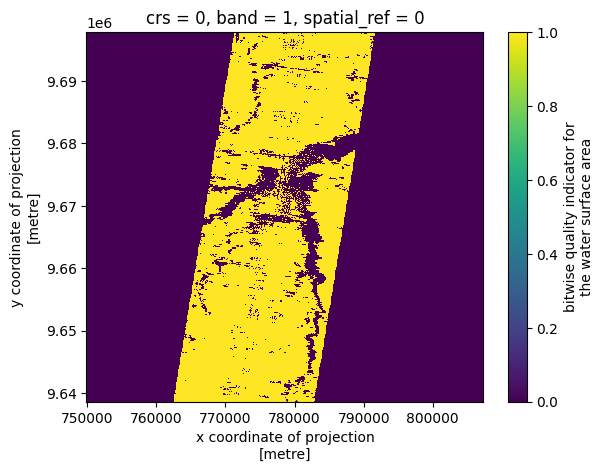

In [138]:
mask = patches[0]["water_area_qual_bitwise"].copy()
mask.data = no_data_mask
mask.plot()

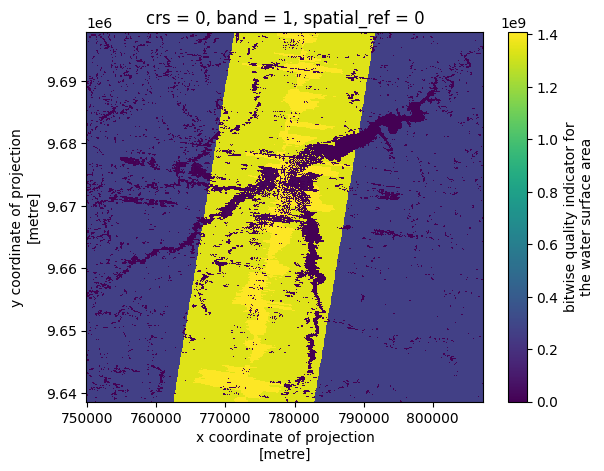

In [136]:
patches[0]["water_area_qual_bitwise"].plot()

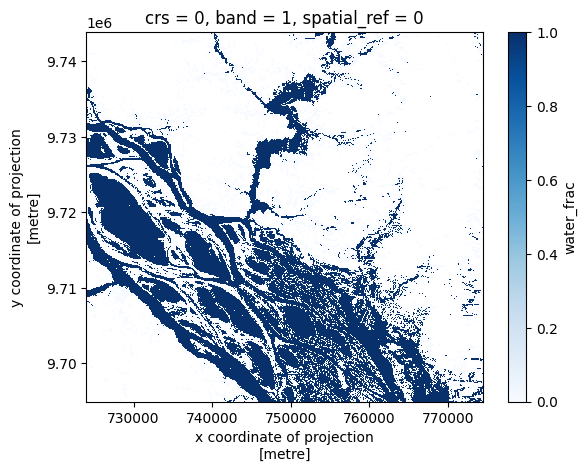

In [58]:
swot_mask.where(swot_mask != 3).plot(cmap="Blues")

In [18]:
ref_mask = datasets["ref_mask"]
np.unique(ref_mask.data), bool(ref_mask.isnull().any())

(array([0, 1], dtype=uint8), False)

In [19]:
swot_mask, patches = create_raster_mosaic(
    mosaic_df,
    ref_date=DATE,
    aoi=aoi,
    variable="water_frac",
    exclude_flags=None,
    exclude_no_data=True,
)
swot_mask = swot_mask["water_frac"]
swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.6)] = 0  # not water
swot_mask.data[swot_mask.data < -1] = 0  # not water
swot_mask.data[swot_mask.data == -1] = 3  # flagged
swot_mask = swot_mask.fillna(1).astype("uint8")

In [20]:
np.unique(swot_mask.data)

array([0, 1], dtype=uint8)

In [21]:
calc_metrics(ref_mask, swot_mask, metrics, binary=True)

,0
iou,0.7684
f1,0.8690
precision,0.9004
recall,0.8398
coverage,1.0000
water_coverage,1.0000


In [22]:
calc_metrics(swot_mask, ref_mask, metrics, binary=True)

,0
iou,0.7684
f1,0.8690
precision,0.8398
recall,0.9004
coverage,1.0000
water_coverage,1.0000


In [23]:
swot_mask_projected = swot_mask.rio.reproject_match(
    ref_mask,
    resampling=Resampling.mode,
    # nodata=2,
)

In [24]:
np.unique(swot_mask_projected.data)

array([  0,   1, 255], dtype=uint8)

In [25]:
ref_mask_projected = ref_mask.rio.reproject_match(swot_mask, resampling=Resampling.mode)

In [26]:
np.unique(ref_mask.data)

array([0, 1], dtype=uint8)

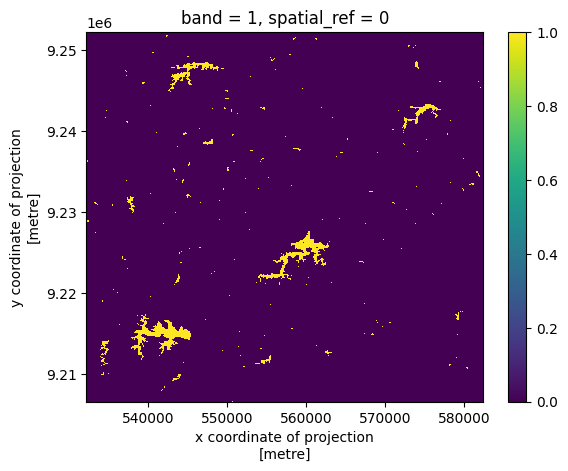

In [27]:
ref_mask_projected.plot()

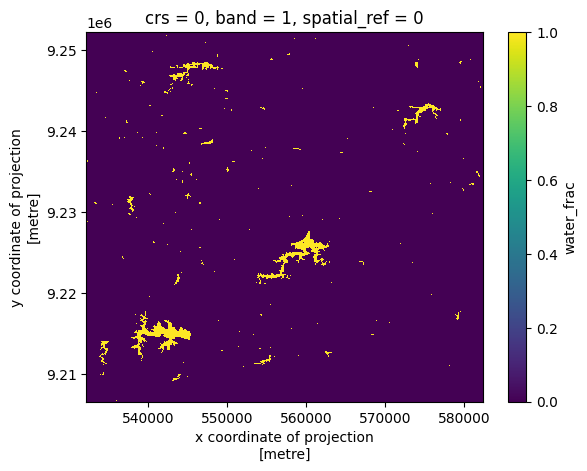

In [28]:
swot_mask.plot()

In [29]:
display(calc_metrics(ref_mask_projected, swot_mask, metrics, binary=True))
display(calc_metrics(swot_mask, ref_mask_projected, metrics, binary=True))


,0
iou,0.7684
f1,0.8690
precision,0.9004
recall,0.8398
coverage,1.0000
water_coverage,1.0000


,0
iou,0.7684
f1,0.8690
precision,0.8398
recall,0.9004
coverage,1.0000
water_coverage,1.0000


In [30]:
from swot_toolkit.metrics import match_projections

swot_mask_proj, ref_mask_proj = match_projections([swot_mask, ref_mask])

In [31]:
ref_mask.size

23019090

In [32]:
swot_mask_proj.size, ref_mask_proj.size

(229368, 229368)

In [33]:
np.unique(swot_mask.data)

array([0, 1], dtype=uint8)

In [34]:
ref_mask.size

23019090

In [35]:
sizes = [x.size for x in [swot_mask, ref_mask]]
sizes

[229368, 23019090]

In [36]:
np.argmin(sizes)

np.int64(0)

In [37]:
swot_mask_projected.shape

(4570, 5037)

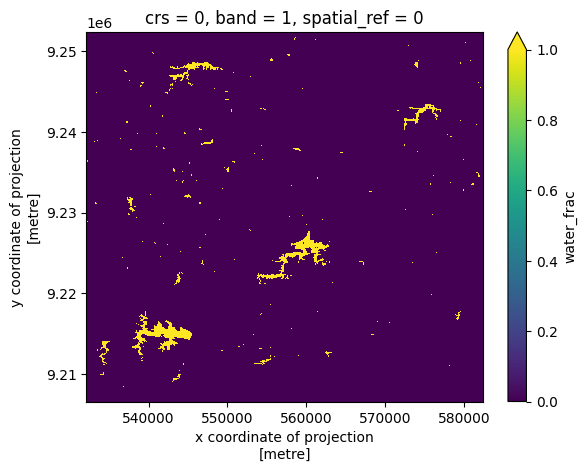

In [38]:
swot_mask_projected.plot(vmin=0, vmax=1)